In [8]:
# pip install gensim

In [9]:
# w2vec model : objective is : it will take any words --> convert into vectors
import gensim.downloader as api

wiki_model = api.load('glove-wiki-gigaword-50')  # Load the pre-trained Word2Vec model
wiki_model.vector_size

50

In [10]:
banana_v = wiki_model['banana']
apple_v = wiki_model['apple']
lemon_v = wiki_model['lemon']
orange_v = wiki_model['orange']
rahul_v = wiki_model['rahul']
aziz_v = wiki_model['aziz']

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity([lemon_v], [rahul_v])

array([[-0.12388498]], dtype=float32)

In [12]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

In [13]:
# words = ["loan", "credit", "finance", "money", "gold","orange", "apple", "banana", "lemon", "rahul", "aziz",'silver','india','usa','uk','europe','asia']
words = ["good", "bad", "happy", "sad", "angry", "joyful", "miserable", "excited", "depressed", "content"]
word_vectors = [wiki_model[word] for word in words]
word_vectors[3]

array([ 0.18822 ,  0.52772 , -0.80729 , -0.18974 ,  0.73361 , -0.52599 ,
        0.73379 ,  1.151   , -1.0057  ,  0.53222 , -0.53503 , -0.46232 ,
       -0.35761 , -0.089558,  1.1745  ,  0.025105, -0.26076 ,  0.57176 ,
        0.51661 ,  0.39261 , -1.2262  ,  0.96739 ,  0.14591 ,  0.67439 ,
        1.0324  , -0.9346  , -1.8862  ,  1.2702  ,  1.0383  , -0.093612,
        1.7631  ,  0.13482 ,  0.6586  ,  0.017446, -0.23751 ,  0.080928,
        0.40966 , -0.56527 ,  0.43035 , -0.30735 , -0.6366  ,  0.042546,
       -0.23112 , -0.46408 , -0.04127 ,  0.86248 , -0.31139 ,  0.37836 ,
        0.037122,  0.74944 ], dtype=float32)

In [14]:
points_2d = pca.fit_transform(word_vectors)

In [15]:
points_2d

array([[ 1.49637456,  0.86194542],
       [ 0.79760946,  2.30350118],
       [-0.24157913, -0.11829892],
       [-1.67929876,  0.51040715],
       [-0.76553847, -1.20142488],
       [-1.90853238, -2.66368668],
       [-1.55327467,  0.9995669 ],
       [-0.19807715, -0.95247096],
       [-0.31392666,  1.72542993],
       [ 4.36624319, -1.46496915]])

In [16]:
# pip install matplotlib

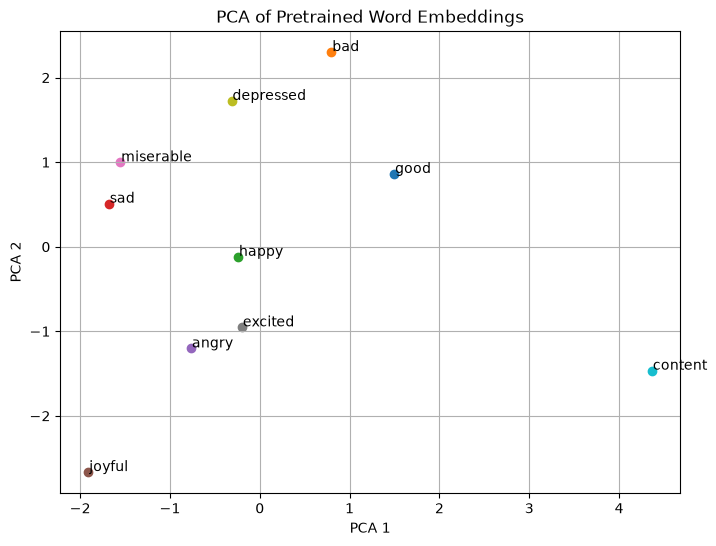

In [17]:
import matplotlib.pyplot as plt

plt
plt.figure(figsize=(8, 6))
for i, word in enumerate(words):
    x = points_2d[i, 0]
    y = points_2d[i, 1]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=10)

plt.title("PCA of Pretrained Word Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

In [18]:

DOCS = [
    "Gold loan foreclosure attracts 2% penalty if closed within 6 months of disbursal. No penalty after 6 months.",
    "Personal loan EMI is auto-debited on the 5th of every month. Insufficient funds attract a late fee of Rs 1000.",
    "Customers with CIBIL score below 650 are ineligible for a new personal loan or top-up loan.",
    "Loan renewal is available for Tier 1 and Tier 2 city customers with repayment score above 700 and no defaults in last 12 months.",
    "Gold loan renewal maximum is Rs 1,00,000 for salaried customers and Rs 50,000 for self-employed customers.",
    # add some irrelvent topics here
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is transforming the tech industry.",
    "Machine learning is a subset of AI.",
    "Deep learning is a specialized form of machine learning.",
    "Natural language processing enables machines to understand human language.",
    "Machine learniong need maths understadbning"
]


# avg w2vec
import numpy as np
def average_word_vectors(docs, model):
    avg_vectors = []
    for doc in docs:
        words = doc.split()
        word_vecs = [model[word] for word in words if word in model]
        if word_vecs:
            avg_vectors.append(np.mean(word_vecs, axis=0))
        else:
            avg_vectors.append(np.zeros(model.vector_size))
    return np.array(avg_vectors)

def query_vector_fn(query, model):
    avg_vector = np.zeros(model.vector_size)
    for word in query.split():
        if word in model:
            avg_vector += model[word]
    return avg_vector / len(query.split())


In [19]:
# query_vector_fn("what is a gold loan?", wiki_model)

In [20]:
vectors_store = average_word_vectors(DOCS, wiki_model)

In [ ]:
# search function
def search(query, vectors_store, model, docs, top_n=3):
    similarities = cosine_similarity([query], vectors_store)[0]
    top_indices = similarities.argsort()[-top_n:][::-1]
    return [(docs[i], similarities[i]) for i in top_indices]



In [26]:
query = "well"
query_vector = query_vector_fn(query, wiki_model)
search_results = search(query_vector, vectors_store, wiki_model, DOCS)

In [27]:
search_results

[('Deep learning is a specialized form of machine learning.',
  np.float64(0.9004235645100617)),
 ('Loan renewal is available for Tier 1 and Tier 2 city customers with repayment score above 700 and no defaults in last 12 months.',
  np.float64(0.887503956702457)),
 ('Personal loan EMI is auto-debited on the 5th of every month. Insufficient funds attract a late fee of Rs 1000.',
  np.float64(0.8866875869787124))]

In [29]:
# pip install sentence_transformers

In [1]:
from sentence_transformers import SentenceTransformer
sentence_model = SentenceTransformer("all-MiniLM-L6-v2")

/Users/rahultiwari/Documents/aziz_ai_engineering/ai-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9582.41it/s]


In [9]:

DOCS = [
    "Gold loan foreclosure attracts 2% penalty if closed within 6 months of disbursal. No penalty after 6 months.",
    "Personal loan EMI is auto-debited on the 5th of every month. Insufficient funds attract a late fee of Rs 1000.",
    "Customers with CIBIL score below 650 are ineligible for a new personal loan or top-up loan.",
    "Loan renewal is available for Tier 1 and Tier 2 city customers with repayment score above 700 and no defaults in last 12 months.",
    "Gold loan renewal maximum is Rs 1,00,000 for salaried customers and Rs 50,000 for self-employed customers.",
    # add some irrelvent topics here
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is transforming the tech industry.",
    "Machine learning is a subset of AI.",
    "Deep learning is a specialized form of machine learning.",
    "Natural language processing enables machines to understand human language.",
    "Machine learning needs maths understanding."
]


vector_store = sentence_model.encode(DOCS)  


In [2]:
from sklearn.metrics.pairwise import cosine_similarity
def search_sentence_transformers(query, vector_store, top_k=5):
    query_vector = sentence_model.encode(query)
    similarities = cosine_similarity([query_vector], vector_store)
    top_k_indices = similarities[0].argsort()[-top_k:][::-1]
    # return the top_k most similar documents
    return [DOCS[i] for i in top_k_indices]


In [18]:
query = "what is machine learning"
search_results = search_sentence_transformers(query, vector_store)

In [19]:
search_results

['Machine learning is a subset of AI.',
 'Deep learning is a specialized form of machine learning.',
 'Machine learning needs maths understanding.',
 'Artificial intelligence is transforming the tech industry.',
 'Natural language processing enables machines to understand human language.']

In [3]:
# sentence_vectors = sentence_model.encode("I am working on a project.")

In [4]:
# len(sente_vectors)

In [5]:
# sentence_vectors

In [3]:
# lets load the llm.txt file
with open("llm.txt", "r") as file:
    llm_text = file.read()
    

In [10]:
# lets split it based on paragraphs
llm_sentences = llm_text.split("\n\n")
vector_store = sentence_model.encode(llm_sentences)


In [13]:
def search_sentence_transformers(query, vector_store, top_k=5):
    query_vector = sentence_model.encode(query)
    similarities = cosine_similarity([query_vector], vector_store)
    top_k_indices = similarities[0].argsort()[-top_k:][::-1]
    # return the top_k most similar documents
    return [llm_sentences[i] for i in top_k_indices]

In [16]:
query = "what is the objective of Mixture of experts"
search_results = search_sentence_transformers(query, vector_store)

In [17]:
search_results

['Mixture of experts\nMain article: Mixture of experts\nA mixture of experts (MoE) is a machine learning architecture in which multiple specialized neural networks ("experts") work together, with a gating mechanism that routes each input to the most appropriate expert(s). Mixtures of experts can reduce inference costs, as only a fraction of the parameters are used for each input.[38]',
 'Since 2023, many LLMs have been trained to be multimodal, having the ability to also process or generate other types of data, such as images, audio, or 3D meshes.[citation needed]',
 "Biased or inaccurate training data can make an LLM's output less reliable. Benchmark evaluations for LLMs attempt to measure model reasoning, factual accuracy, alignment, and safety.",
 "Fine-tuning\nBefore being fine-tuned, most LLMs are next-token predictors.[28] The fine-tuning shapes the LLM's behavior via techniques like reinforcement learning from human feedback (RLHF) or constitutional AI.[29]",
 'When each head ca